# 🛢️ Crude Oil Price Analysis & Forecasting (1970–2026)
### Notebook 01 — Exploratory Data Analysis

**What this notebook covers:**
1. Quick-start (Drive mount + data load)
2. Hero chart — full price series with geopolitical event annotations
3. Price distribution & statistical summary
4. Decade-by-decade breakdown
5. Seasonal patterns (month-of-year analysis)
6. Rolling volatility & regime analysis
7. Stationarity testing (ADF test)
8. ACF / PACF — autocorrelation structure
9. Log-returns distribution
10. Correlation heatmap of engineered features

> **Prerequisite:** Run `00_project_setup.ipynb` at least once before this notebook.

---

## 0 — Quick-Start Block

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('deep')

PROJECT_ROOT = '/content/drive/MyDrive/crude_oil_project'
PATHS = {
    'root':      PROJECT_ROOT,
    'data':      os.path.join(PROJECT_ROOT, 'data'),
    'models':    os.path.join(PROJECT_ROOT, 'models'),
    'figures':   os.path.join(PROJECT_ROOT, 'outputs', 'figures'),
    'forecasts': os.path.join(PROJECT_ROOT, 'outputs', 'forecasts'),
}

df = pd.read_csv(
    os.path.join(PATHS['data'], 'oil_clean.csv'),
    index_col='Date', parse_dates=True
)
df.index = pd.DatetimeIndex(df.index, freq='MS')

FIGSIZE  = (14, 5)
C_BLUE   = '#3266AD'
C_RED    = '#E8593C'
C_AMBER  = '#D4930A'
C_GRAY   = '#888780'
C_TEAL   = '#1D9E75'
C_PURPLE = '#7F77DD'

print(f"✅ Ready — {len(df)} rows loaded ({df.index.min().date()} → {df.index.max().date()})")

Mounted at /content/drive
✅ Ready — 675 rows loaded (1970-01-01 → 2026-03-01)


---
## 1 — Hero Chart: Full Price Series with Geopolitical Annotations

This is the **portfolio centrepiece** for this project.  
Each annotated event is linked to a quantified price impact computed automatically from the data.

In [2]:
# ── Define geopolitical events ─────────────────────────────────────────────
# Format: (date, short_label, full_description, vertical_offset_for_label)
EVENTS = [
    ('1973-10-01', '1973\nOil Embargo',    'OPEC Arab oil embargo',               +55),
    ('1979-01-01', '1979\nIran Rev.',      'Iranian Revolution & oil shock',       +55),
    ('1986-01-01', '1986\nOPEC Crash',     'OPEC production surge, price collapse',-60),
    ('1990-08-01', '1990\nGulf War',       'Iraq invades Kuwait',                  +55),
    ('1998-12-01', '1998\nAsian Crisis',   'Asian financial crisis demand drop',   -60),
    ('2008-07-01', '2008\nAll-time High',  'Record high before financial crisis',  +55),
    ('2008-12-01', '2008\nGFC Crash',      'Global Financial Crisis demand shock', -60),
    ('2014-11-01', '2014\nOPEC War',       'OPEC refuses to cut production',       +55),
    ('2020-04-01', '2020\nCOVID Crash',    'COVID-19 demand collapse',             -60),
    ('2022-03-01', '2022\nUkraine War',    'Russia invades Ukraine, supply shock', +55),
]

# Compute price at each event date
for i, (date_str, label, desc, offset) in enumerate(EVENTS):
    ts = pd.Timestamp(date_str)
    price = df.loc[ts, 'price'] if ts in df.index else np.nan
    print(f"  {date_str}  ${price:6.2f}/bbl  {label.replace(chr(10), ' ')}")

print(f"\n  All-time low  : ${df['price'].min():.2f} on {df['price'].idxmin().date()}")
print(f"  All-time high : ${df['price'].max():.2f} on {df['price'].idxmax().date()}")

  1973-10-01  $  4.10/bbl  1973 Oil Embargo
  1979-01-01  $ 17.45/bbl  1979 Iran Rev.
  1986-01-01  $ 24.68/bbl  1986 OPEC Crash
  1990-08-01  $ 26.40/bbl  1990 Gulf War
  1998-12-01  $ 10.41/bbl  1998 Asian Crisis
  2008-07-01  $132.83/bbl  2008 All-time High
  2008-12-01  $ 41.34/bbl  2008 GFC Crash
  2014-11-01  $ 76.99/bbl  2014 OPEC War
  2020-04-01  $ 21.04/bbl  2020 COVID Crash
  2022-03-01  $112.40/bbl  2022 Ukraine War

  All-time low  : $1.21 on 1970-01-01
  All-time high : $132.83 on 2008-07-01


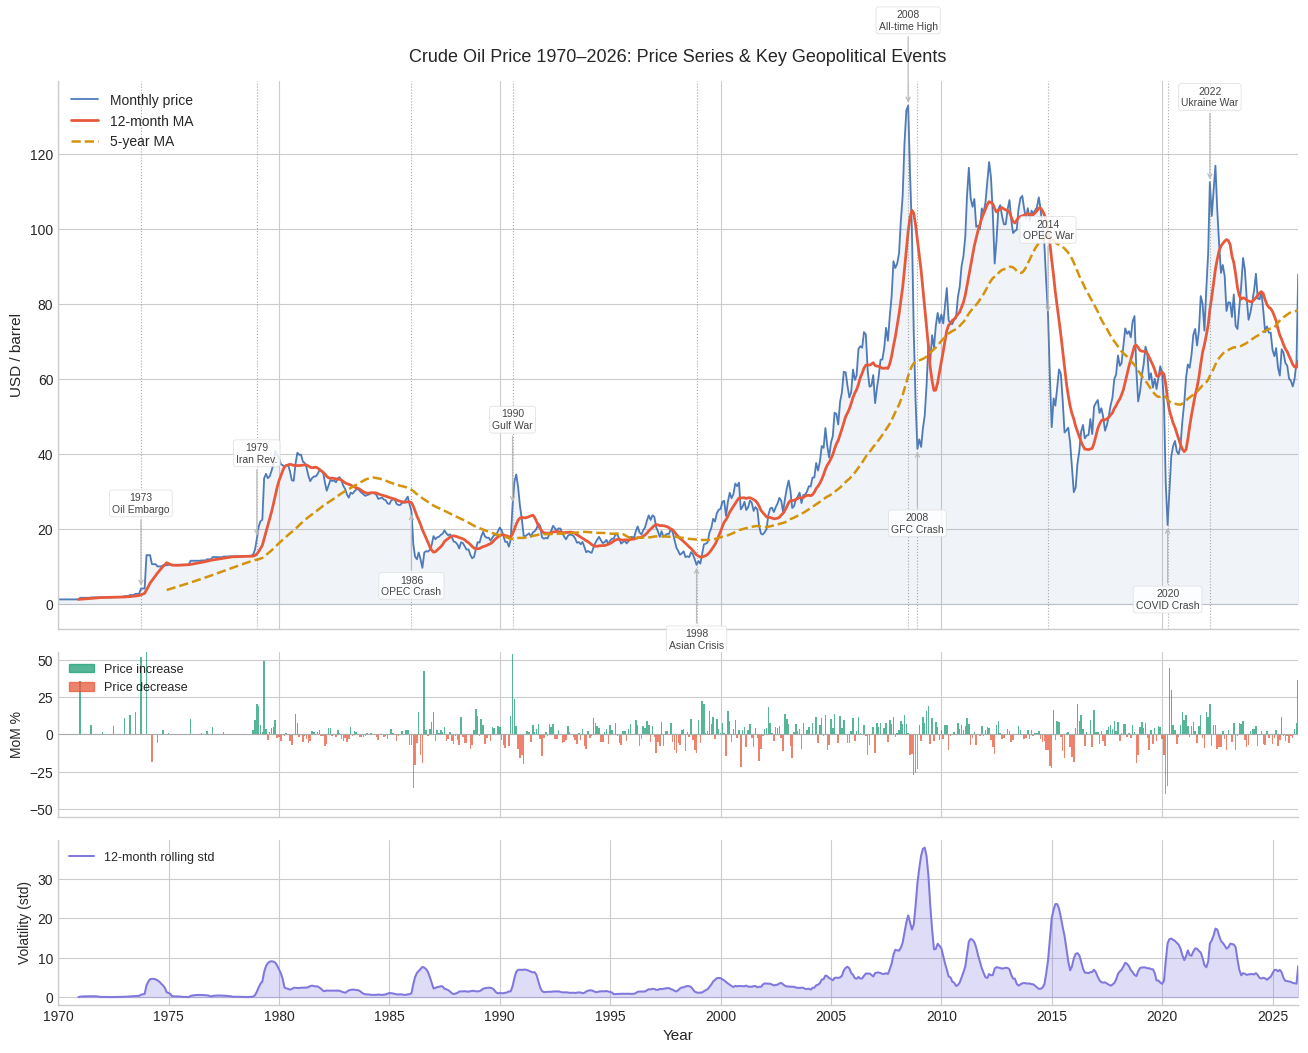


✅ Hero chart saved → /content/drive/MyDrive/crude_oil_project/outputs/figures/01_hero_chart.png


In [3]:
fig, axes = plt.subplots(
    3, 1, figsize=(16, 12),
    gridspec_kw={'height_ratios': [4, 1.2, 1.2], 'hspace': 0.08}
)

# ── Panel 1: Price series + moving averages ────────────────────────────────
ax1 = axes[0]
ax1.fill_between(df.index, df['price'], alpha=0.07, color=C_BLUE)
ax1.plot(df.index, df['price'],          color=C_BLUE,   lw=1.3, alpha=0.85, label='Monthly price')
ax1.plot(df.index, df['rolling_mean_12'],color=C_RED,    lw=2.0, label='12-month MA')
ax1.plot(df.index, df['rolling_mean_60'],color=C_AMBER,  lw=1.8, ls='--', label='5-year MA')

ax1.set_ylabel('USD / barrel', fontsize=11)
ax1.set_title('Crude Oil Price 1970–2026: Price Series & Key Geopolitical Events',
              fontsize=13, fontweight='medium', pad=14)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.85)
ax1.set_xlim(df.index.min(), df.index.max())
ax1.tick_params(labelbottom=False)

# Draw event annotations
for date_str, label, desc, y_offset in EVENTS:
    ts = pd.Timestamp(date_str)
    if ts not in df.index:
        continue
    price_val = df.loc[ts, 'price']
    ax1.axvline(ts, color=C_GRAY, lw=0.8, ls=':', alpha=0.7)
    ax1.annotate(
        label,
        xy=(ts, price_val),
        xytext=(0, y_offset),
        textcoords='offset points',
        fontsize=7.5,
        ha='center',
        color='#444',
        arrowprops=dict(arrowstyle='->', color='#bbb', lw=0.9),
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#ddd', alpha=0.85, lw=0.6)
    )

# ── Panel 2: Month-over-month % change ────────────────────────────────────
ax2 = axes[1]
pct = df['pct_change'].fillna(0)
colors_bar = [C_TEAL if v >= 0 else C_RED for v in pct]
ax2.bar(df.index, pct, color=colors_bar, width=25, alpha=0.75)
ax2.axhline(0, color='#aaa', lw=0.8)
ax2.set_ylabel('MoM %', fontsize=10)
ax2.set_ylim(-55, 55)
ax2.tick_params(labelbottom=False)
ax2.set_xlim(df.index.min(), df.index.max())
patch_up   = mpatches.Patch(color=C_TEAL, alpha=0.75, label='Price increase')
patch_down = mpatches.Patch(color=C_RED,  alpha=0.75, label='Price decrease')
ax2.legend(handles=[patch_up, patch_down], fontsize=9, loc='upper left', framealpha=0.85)

# ── Panel 3: 12-month rolling volatility ──────────────────────────────────
ax3 = axes[2]
ax3.fill_between(df.index, df['rolling_std_12'], alpha=0.25, color=C_PURPLE)
ax3.plot(df.index, df['rolling_std_12'], color=C_PURPLE, lw=1.4, label='12-month rolling std')
ax3.set_ylabel('Volatility (std)', fontsize=10)
ax3.set_xlabel('Year', fontsize=11)
ax3.set_xlim(df.index.min(), df.index.max())
ax3.legend(fontsize=9, loc='upper left', framealpha=0.85)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
save_path = os.path.join(PATHS['figures'], '01_hero_chart.png')
plt.savefig(save_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"\n✅ Hero chart saved → {save_path}")

---
## 2 — Price Distribution Analysis

Is crude oil price normally distributed? Spoiler: it isn't.  
We test this formally and look at the distribution of log-returns.

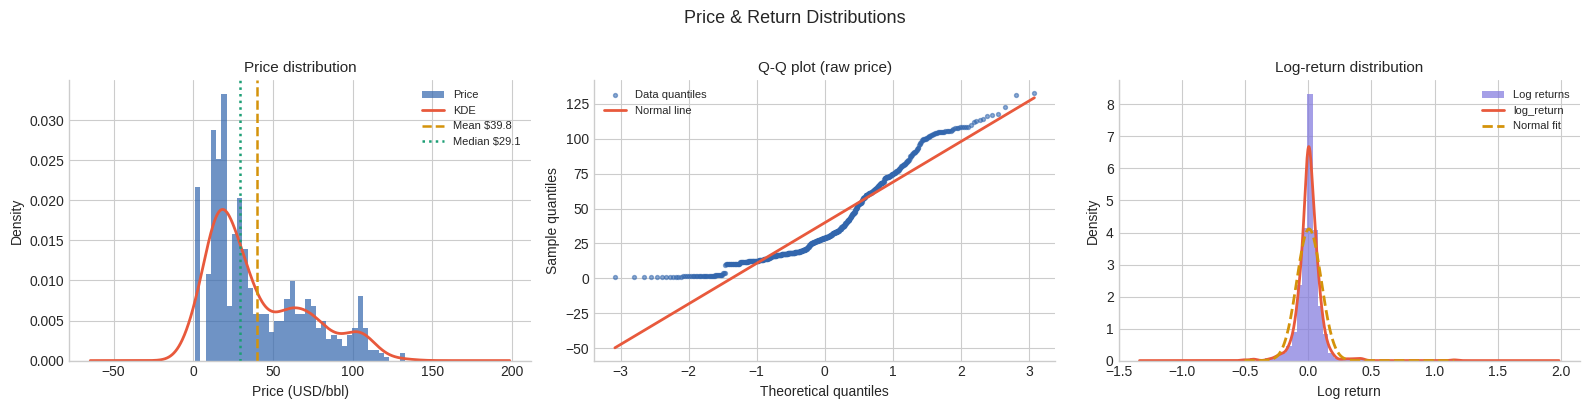

Normality tests (price)
------------------------------------------
  Shapiro-Wilk W = 0.8959,  p = 5.63e-21  → NOT normal
  KS test      D = 0.1559,  p = 8.45e-15  → NOT normal

  Skewness  : 0.885  (>0 = right-skewed)
  Kurtosis  : -0.243 (>0 = heavy tails vs normal)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Left: histogram + KDE of raw price ────────────────────────────────────
ax = axes[0]
ax.hist(df['price'], bins=40, color=C_BLUE, alpha=0.7, density=True, label='Price')
df['price'].plot.kde(ax=ax, color=C_RED, lw=2, label='KDE')
ax.axvline(df['price'].mean(),   color=C_AMBER,  lw=1.8, ls='--', label=f"Mean ${df['price'].mean():.1f}")
ax.axvline(df['price'].median(), color=C_TEAL,   lw=1.8, ls=':',  label=f"Median ${df['price'].median():.1f}")
ax.set_xlabel('Price (USD/bbl)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Price distribution', fontsize=11, fontweight='medium')
ax.legend(fontsize=8)

# ── Middle: Q-Q plot ───────────────────────────────────────────────────────
ax = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(df['price'].dropna(), dist='norm', fit=True)
ax.scatter(osm, osr, s=8, color=C_BLUE, alpha=0.55, label='Data quantiles')
ax.plot(osm, slope * np.array(osm) + intercept, color=C_RED, lw=2, label='Normal line')
ax.set_xlabel('Theoretical quantiles', fontsize=10)
ax.set_ylabel('Sample quantiles', fontsize=10)
ax.set_title('Q-Q plot (raw price)', fontsize=11, fontweight='medium')
ax.legend(fontsize=8)

# ── Right: log-return distribution vs normal ───────────────────────────────
ax = axes[2]
log_ret = df['log_return'].dropna()
ax.hist(log_ret, bins=40, color=C_PURPLE, alpha=0.7, density=True, label='Log returns')
log_ret.plot.kde(ax=ax, color=C_RED, lw=2)
mu, std = log_ret.mean(), log_ret.std()
x = np.linspace(log_ret.min(), log_ret.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu, std), color=C_AMBER, lw=2, ls='--', label='Normal fit')
ax.set_xlabel('Log return', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Log-return distribution', fontsize=11, fontweight='medium')
ax.legend(fontsize=8)

plt.suptitle('Price & Return Distributions', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Normality tests ────────────────────────────────────────────────────────
print("Normality tests (price)")
print("-" * 42)
stat, p = stats.shapiro(df['price'].dropna().sample(min(5000, len(df)), random_state=42))
print(f"  Shapiro-Wilk W = {stat:.4f},  p = {p:.2e}  {'→ NOT normal' if p < 0.05 else '→ normal'}")
stat, p = stats.kstest(df['price'].dropna(), 'norm',
                        args=(df['price'].mean(), df['price'].std()))
print(f"  KS test      D = {stat:.4f},  p = {p:.2e}  {'→ NOT normal' if p < 0.05 else '→ normal'}")

print(f"\n  Skewness  : {df['price'].skew():.3f}  (>0 = right-skewed)")
print(f"  Kurtosis  : {df['price'].kurtosis():.3f} (>0 = heavy tails vs normal)")

---
## 3 — Decade-by-Decade Breakdown

Oil markets don't behave the same across decades.  
This section quantifies how price level, spread, and volatility shifted over time.

In [5]:
decade_stats = df.groupby('decade')['price'].agg(
    Mean='mean', Median='median', Std='std',
    Min='min', Max='max'
).round(2)
decade_stats['Range']     = (decade_stats['Max'] - decade_stats['Min']).round(2)
decade_stats['CV (%)']    = (decade_stats['Std'] / decade_stats['Mean'] * 100).round(1)

print("Decade-by-Decade Price Statistics (USD/barrel)")
print("=" * 65)
print(decade_stats.to_string())
print()
print("CV = Coefficient of Variation (std / mean × 100) — measures relative volatility")

Decade-by-Decade Price Statistics (USD/barrel)
         Mean  Median    Std    Min     Max   Range  CV (%)
decade                                                     
1970     9.70   10.42   8.89   1.21   40.75   39.54    91.6
1980    25.55   27.84   8.35   9.62   40.30   30.68    32.7
1990    18.19   17.90   3.84  10.41   34.50   24.09    21.1
2000    49.17   42.10  25.64  18.52  132.83  114.31    52.1
2010    76.45   74.65  24.31  29.78  117.78   88.00    31.8
2020    71.75   72.87  18.80  21.04  116.80   95.76    26.2

CV = Coefficient of Variation (std / mean × 100) — measures relative volatility


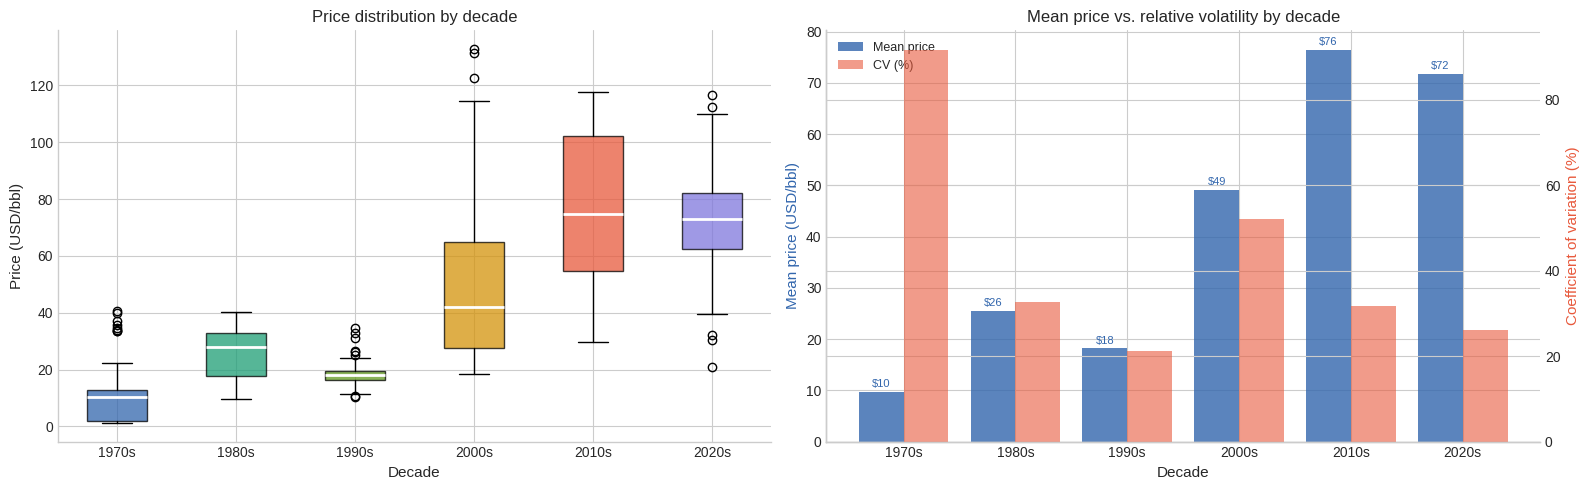

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: boxplot by decade ────────────────────────────────────────────────
ax = axes[0]
decade_groups = [df[df['decade'] == d]['price'].values for d in sorted(df['decade'].unique())]
labels = [f"{d}s" for d in sorted(df['decade'].unique())]
bp = ax.boxplot(decade_groups, labels=labels, patch_artist=True, notch=False,
                medianprops=dict(color='white', lw=2))
palette = [C_BLUE, C_TEAL, C_GREEN := '#639922', C_AMBER, C_RED, C_PURPLE, '#D4537E']
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xlabel('Decade', fontsize=11)
ax.set_ylabel('Price (USD/bbl)', fontsize=11)
ax.set_title('Price distribution by decade', fontsize=12, fontweight='medium')

# ── Right: mean price + CV bar chart ──────────────────────────────────────
ax2 = axes[1]
decades = decade_stats.index.astype(str).str[:3] + "0s"
x = np.arange(len(decades))
width = 0.4
bars1 = ax2.bar(x - width/2, decade_stats['Mean'],  width, color=C_BLUE,   alpha=0.8, label='Mean price')
ax2.set_xlabel('Decade', fontsize=11)
ax2.set_ylabel('Mean price (USD/bbl)', fontsize=11, color=C_BLUE)
ax2.set_title('Mean price vs. relative volatility by decade', fontsize=12, fontweight='medium')
ax2.set_xticks(x)
ax2.set_xticklabels(decades)
ax_cv = ax2.twinx()
ax_cv.bar(x + width/2, decade_stats['CV (%)'], width, color=C_RED, alpha=0.6, label='CV (%)')
ax_cv.set_ylabel('Coefficient of variation (%)', fontsize=11, color=C_RED)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax_cv.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

for bar, val in zip(bars1, decade_stats['Mean']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'${val:.0f}', ha='center', va='bottom', fontsize=8, color=C_BLUE)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_decade_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4 — Seasonal Patterns

Does crude oil show consistent monthly seasonality?  
We look at two angles: average price by calendar month and a 56-year volatility heatmap.

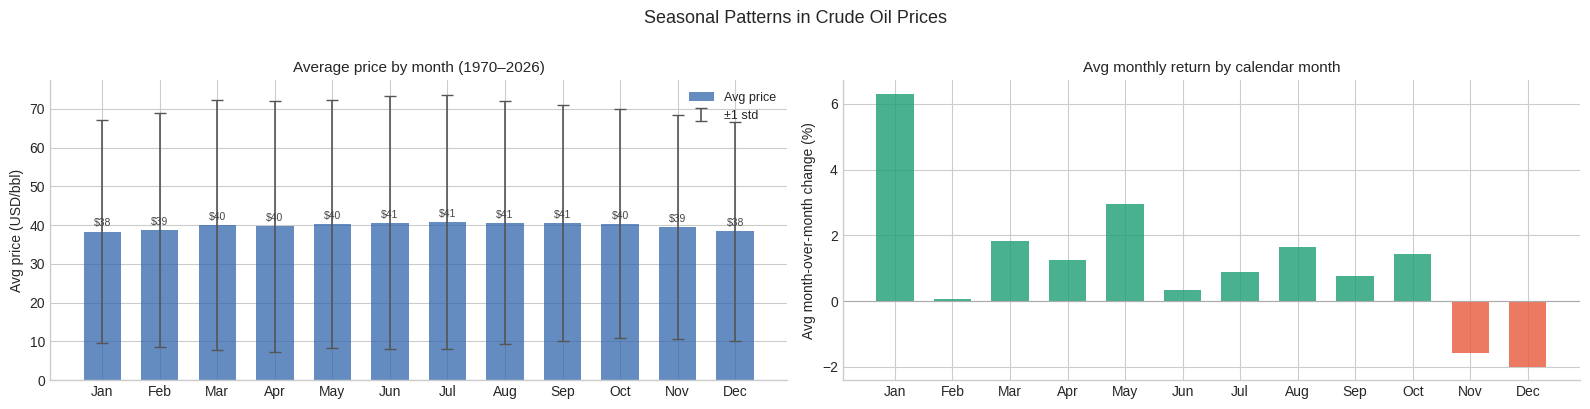


Avg monthly return by calendar month:
  Jan: +6.30%  █████████████████████
  Feb: +0.06%  
  Mar: +1.83%  ██████
  Apr: +1.26%  ████
  May: +2.96%  █████████
  Jun: +0.33%  █
  Jul: +0.90%  ██
  Aug: +1.65%  █████
  Sep: +0.78%  ██
  Oct: +1.43%  ████
  Nov: -1.57%  █████
  Dec: -1.99%  ██████


In [7]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Monthly average price and volatility across all years
monthly_avg = df.groupby('month')['price'].mean()
monthly_std = df.groupby('month')['price'].std()
monthly_ret = df.groupby('month')['pct_change'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ── Left: avg price + std error bars by month ─────────────────────────────
ax = axes[0]
x = np.arange(1, 13)
bars = ax.bar(x, monthly_avg, color=C_BLUE, alpha=0.75, width=0.65, label='Avg price')
ax.errorbar(x, monthly_avg, yerr=monthly_std, fmt='none',
            color='#555', capsize=4, lw=1.2, label='±1 std')
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Avg price (USD/bbl)', fontsize=10)
ax.set_title('Average price by month (1970–2026)', fontsize=11, fontweight='medium')
ax.legend(fontsize=9)
for bar, val in zip(bars, monthly_avg):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'${val:.0f}', ha='center', va='bottom', fontsize=7.5, color='#444')

# ── Right: avg monthly return by month ────────────────────────────────────
ax = axes[1]
bar_colors = [C_TEAL if v >= 0 else C_RED for v in monthly_ret]
ax.bar(x, monthly_ret, color=bar_colors, alpha=0.8, width=0.65)
ax.axhline(0, color='#aaa', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Avg month-over-month change (%)', fontsize=10)
ax.set_title('Avg monthly return by calendar month', fontsize=11, fontweight='medium')

plt.suptitle('Seasonal Patterns in Crude Oil Prices', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_seasonal.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nAvg monthly return by calendar month:")
for m, v in zip(MONTH_NAMES, monthly_ret):
    bar = '█' * int(abs(v) / 0.3) if abs(v) > 0.1 else ''
    sign = '+' if v >= 0 else ''
    print(f"  {m}: {sign}{v:.2f}%  {bar}")

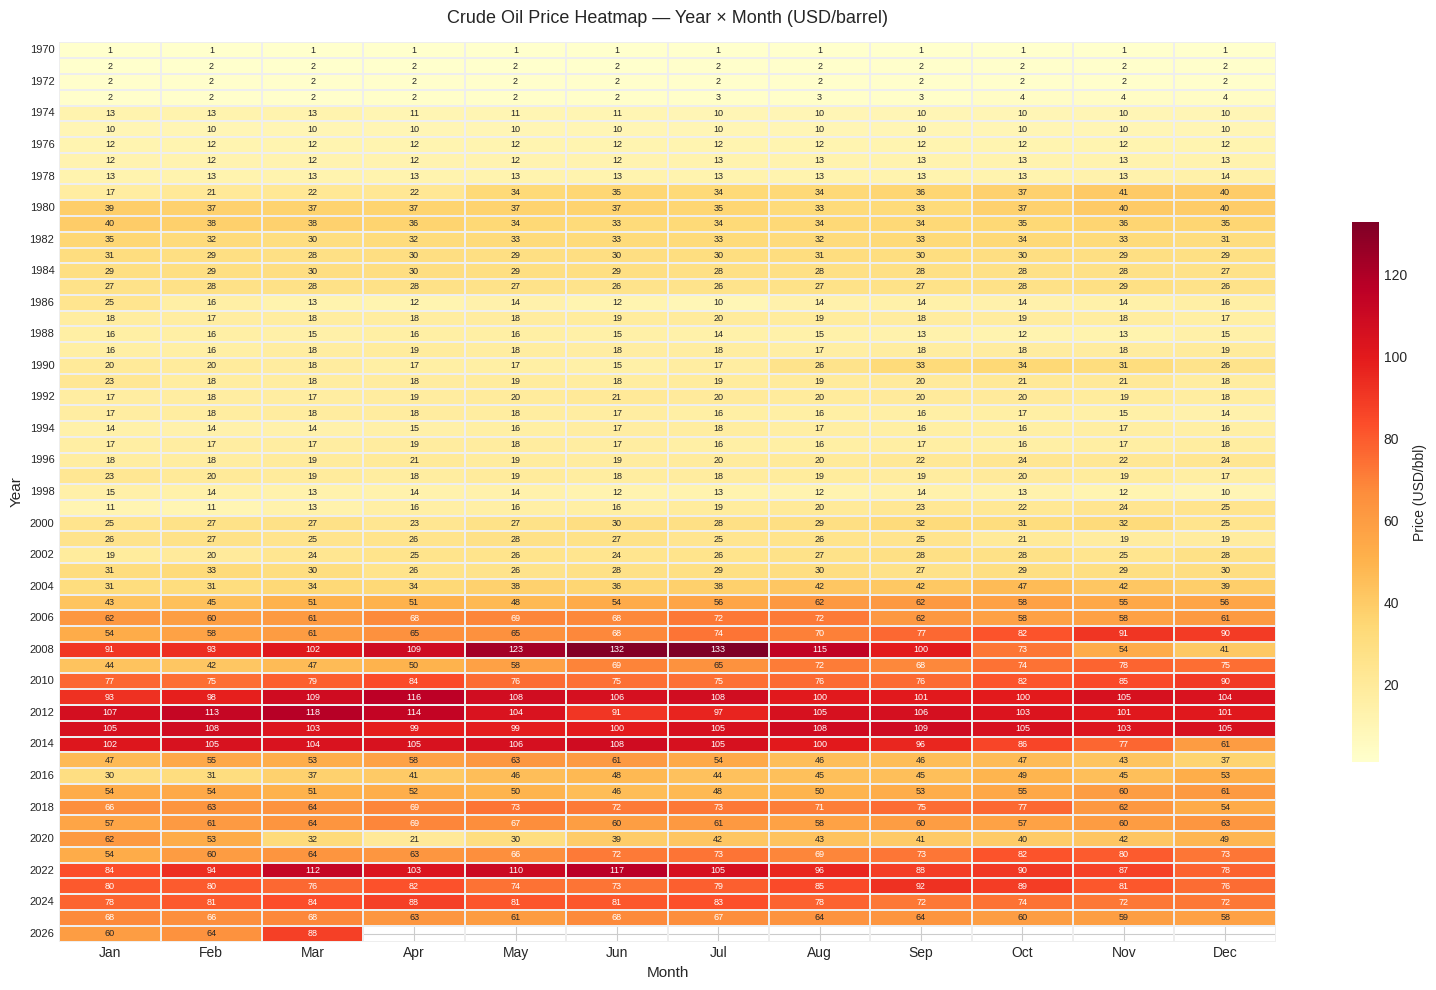

✅ Heatmap saved.


In [8]:
# ── Year × Month price heatmap ─────────────────────────────────────────────
pivot = df.pivot_table(index='year', columns='month', values='price', aggfunc='mean')
pivot.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    pivot, ax=ax,
    cmap='YlOrRd',
    linewidths=0.3, linecolor='#eee',
    fmt='.0f', annot=True, annot_kws={'size': 6.5},
    cbar_kws={'label': 'Price (USD/bbl)', 'shrink': 0.6}
)
ax.set_title('Crude Oil Price Heatmap — Year × Month (USD/barrel)',
             fontsize=13, fontweight='medium', pad=14)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_heatmap_year_month.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved.")

---
## 5 — Time Series Decomposition

Classical decomposition splits the series into Trend + Seasonality + Residual.  
We use multiplicative decomposition because the seasonal swings scale with price level.

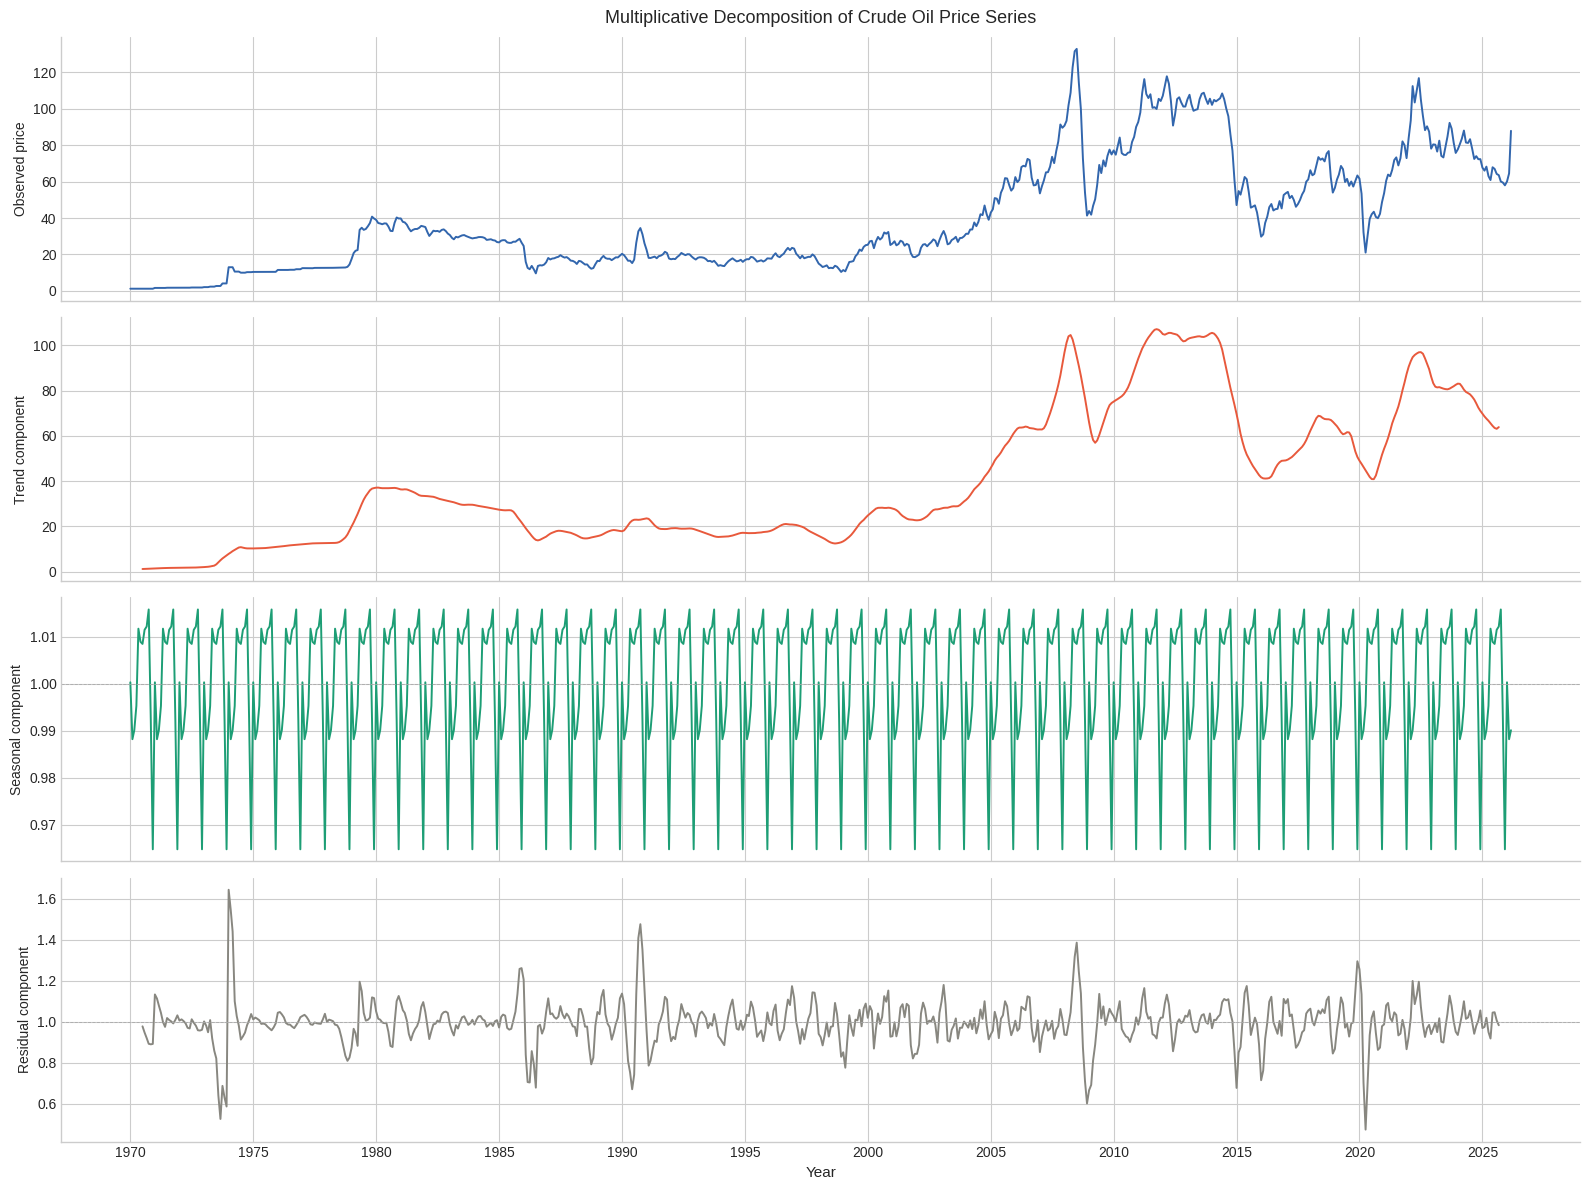

In [11]:
result = seasonal_decompose(df['price'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

components = [
    (result.observed,  'Observed price',    C_BLUE),
    (result.trend,     'Trend component',   C_RED),
    (result.seasonal,  'Seasonal component',C_TEAL),
    (result.resid,     'Residual component',C_GRAY),
]

for ax, (data, label, color) in zip(axes, components):
    ax.plot(data, color=color, lw=1.4)
    ax.set_ylabel(label, fontsize=10)
    # Only draw the baseline for components where y=1 is meaningful
    if label in ('Seasonal component', 'Residual component'):
        ax.axhline(1, color='#aaa', lw=0.6, ls='--')

axes[0].set_title('Multiplicative Decomposition of Crude Oil Price Series',
                  fontsize=13, fontweight='medium', pad=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
axes[-1].set_xlabel('Year', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_decomposition.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6 — Rolling Volatility & Regime Analysis

Volatility in oil markets clusters — calm periods are followed by calm periods, and shocks arrive in bursts.  
This section makes those regimes visible.

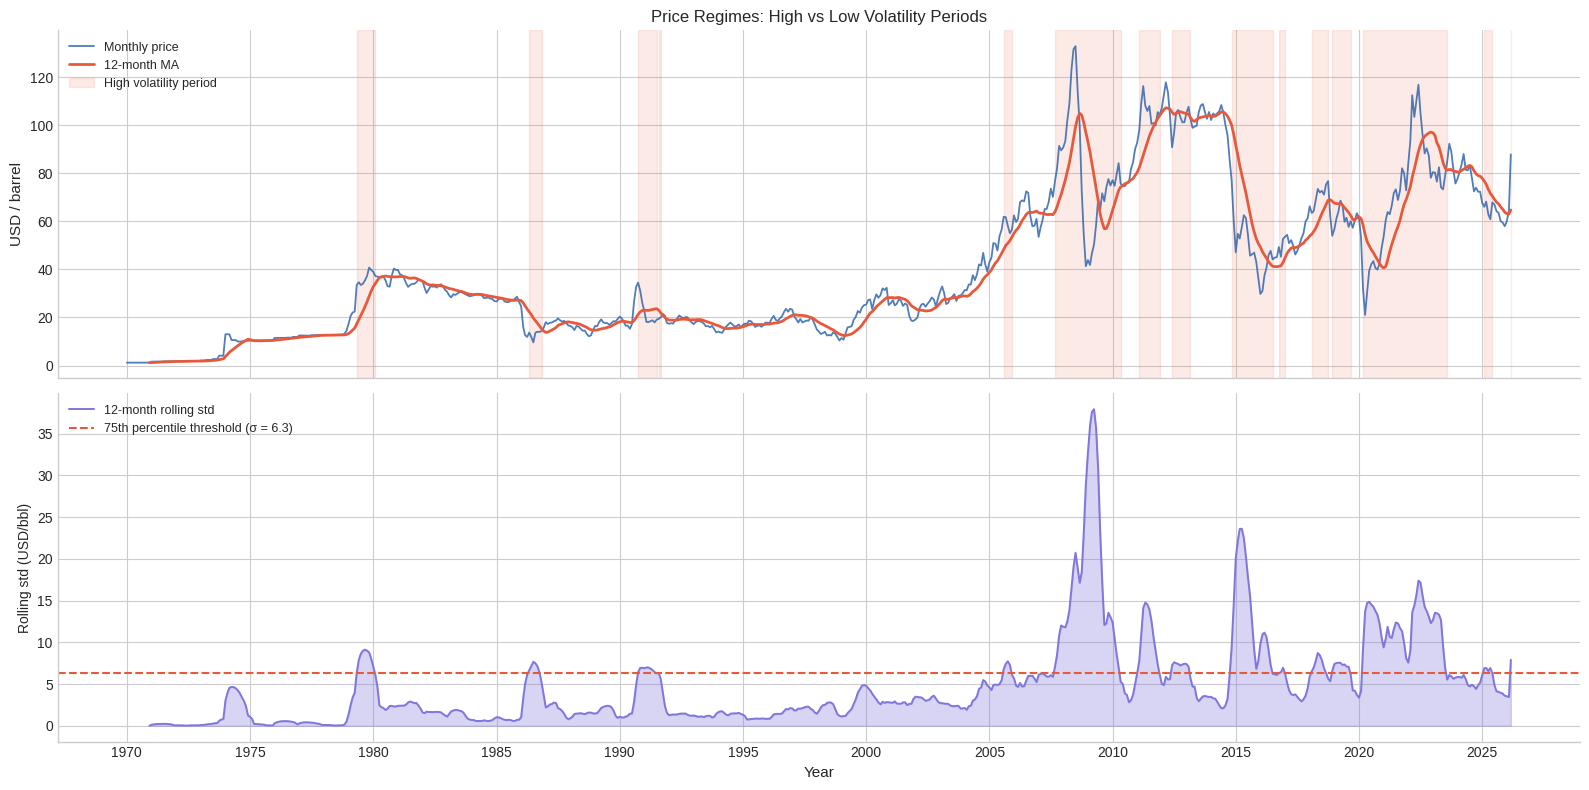

High-volatility months (above 75th pct): 166 / 675 (24.6%)
Volatility threshold                    : σ = $6.31/bbl


In [12]:
# Define high-volatility threshold (top 25% of 12-month rolling std)
vol_threshold = df['rolling_std_12'].quantile(0.75)
high_vol = df['rolling_std_12'] > vol_threshold

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# ── Panel 1: Price with shaded high-volatility regimes ─────────────────────
ax1 = axes[0]
ax1.plot(df.index, df['price'], color=C_BLUE, lw=1.3, alpha=0.85, label='Monthly price')
ax1.plot(df.index, df['rolling_mean_12'], color=C_RED, lw=2, label='12-month MA')

# Shade high-volatility periods
in_regime = False
start = None
for i, (date, is_high) in enumerate(high_vol.items()):
    if is_high and not in_regime:
        start = date
        in_regime = True
    elif not is_high and in_regime:
        ax1.axvspan(start, date, alpha=0.12, color=C_RED, label='High volatility period' if start == high_vol[high_vol].index[0] else '')
        in_regime = False
if in_regime:
    ax1.axvspan(start, df.index[-1], alpha=0.12, color=C_RED)

ax1.set_ylabel('USD / barrel', fontsize=11)
ax1.set_title('Price Regimes: High vs Low Volatility Periods', fontsize=12, fontweight='medium')
ax1.legend(fontsize=9, loc='upper left')

# ── Panel 2: Rolling std with threshold ────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(df.index, df['rolling_std_12'], alpha=0.3, color=C_PURPLE)
ax2.plot(df.index, df['rolling_std_12'], color=C_PURPLE, lw=1.4, label='12-month rolling std')
ax2.axhline(vol_threshold, color=C_RED, lw=1.5, ls='--',
            label=f'75th percentile threshold (σ = {vol_threshold:.1f})')
ax2.set_ylabel('Rolling std (USD/bbl)', fontsize=10)
ax2.set_xlabel('Year', fontsize=11)
ax2.legend(fontsize=9, loc='upper left')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_volatility_regimes.png'), dpi=150, bbox_inches='tight')
plt.show()

n_high_months = high_vol.sum()
print(f"High-volatility months (above 75th pct): {n_high_months} / {len(df)} ({n_high_months/len(df)*100:.1f}%)")
print(f"Volatility threshold                    : σ = ${vol_threshold:.2f}/bbl")

---
## 7 — Stationarity Testing (ADF Test)

ARIMA and most classical forecasting models require a **stationary** series.  
We test the raw price, log-transformed price, and first-differenced price.

In [13]:
def run_adf(series, name):
    series_clean = series.dropna()
    result = adfuller(series_clean, autolag='AIC')
    adf_stat, p_val, lags, n_obs = result[0], result[1], result[2], result[3]
    crit = result[4]
    stationary = p_val < 0.05
    print(f"  {'Series':<28}: {name}")
    print(f"  {'ADF statistic':<28}: {adf_stat:.4f}")
    print(f"  {'p-value':<28}: {p_val:.4f}  →  {'✅ STATIONARY' if stationary else '❌ NON-STATIONARY'}")
    print(f"  {'Lags used':<28}: {lags}")
    for key, val in crit.items():
        marker = '✓' if adf_stat < val else ' '
        print(f"    Critical value {key:<6}: {val:>8.4f}  {marker}")
    print()
    return stationary

print("Augmented Dickey-Fuller Test Results")
print("=" * 52)
print()

s1 = run_adf(df['price'],                  'Raw price')
s2 = run_adf(df['price_log'],             'Log price')
s3 = run_adf(df['price'].diff().dropna(), 'First difference')
s4 = run_adf(df['log_return'].dropna(),   'Log return')

print("─" * 52)
print("Conclusion:")
if not s1 and s3:
    print("  Raw price is I(1) — requires one round of differencing for ARIMA.")
    print("  Log returns are already stationary — use directly for volatility models.")

Augmented Dickey-Fuller Test Results

  Series                      : Raw price
  ADF statistic               : -1.7503
  p-value                     : 0.4054  →  ❌ NON-STATIONARY
  Lags used                   : 6
    Critical value 1%    :  -3.4402   
    Critical value 5%    :  -2.8659   
    Critical value 10%   :  -2.5691   

  Series                      : Log price
  ADF statistic               : -2.8549
  p-value                     : 0.0509  →  ❌ NON-STATIONARY
  Lags used                   : 2
    Critical value 1%    :  -3.4401   
    Critical value 5%    :  -2.8659   
    Critical value 10%   :  -2.5691  ✓

  Series                      : First difference
  ADF statistic               : -11.6389
  p-value                     : 0.0000  →  ✅ STATIONARY
  Lags used                   : 5
    Critical value 1%    :  -3.4402  ✓
    Critical value 5%    :  -2.8659  ✓
    Critical value 10%   :  -2.5691  ✓

  Series                      : Log return
  ADF statistic               : -

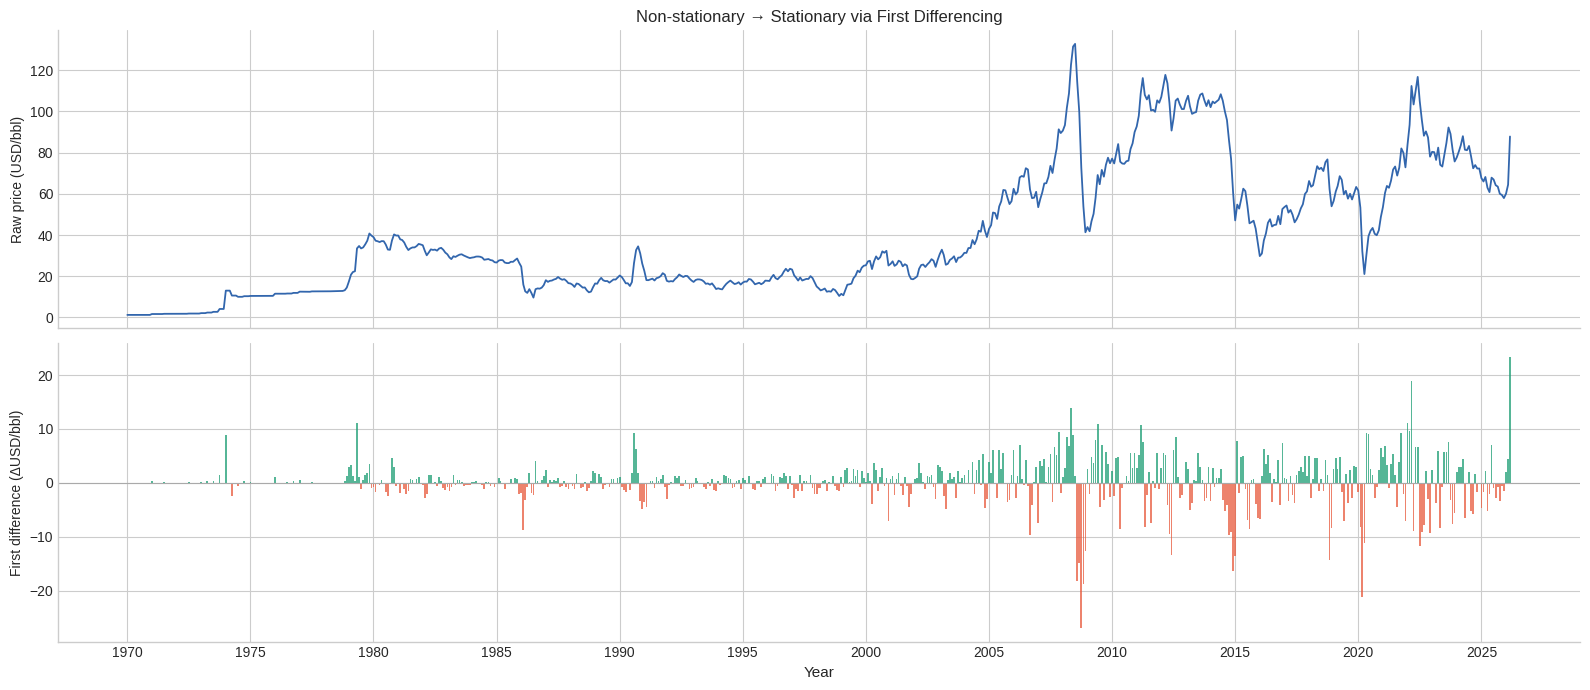

In [14]:
# Visual: raw vs differenced
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df.index, df['price'], color=C_BLUE, lw=1.3)
axes[0].set_ylabel('Raw price (USD/bbl)', fontsize=10)
axes[0].set_title('Non-stationary → Stationary via First Differencing', fontsize=12, fontweight='medium')

diff = df['price'].diff()
colors_diff = [C_TEAL if v >= 0 else C_RED for v in diff.fillna(0)]
axes[1].bar(df.index, diff, color=colors_diff, width=25, alpha=0.75)
axes[1].axhline(0, color='#aaa', lw=0.8)
axes[1].set_ylabel('First difference (ΔUSD/bbl)', fontsize=10)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_stationarity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8 — ACF & PACF Analysis

The autocorrelation and partial autocorrelation functions tell us how many AR and MA terms to include in ARIMA.  
We plot both for the differenced (stationary) series.

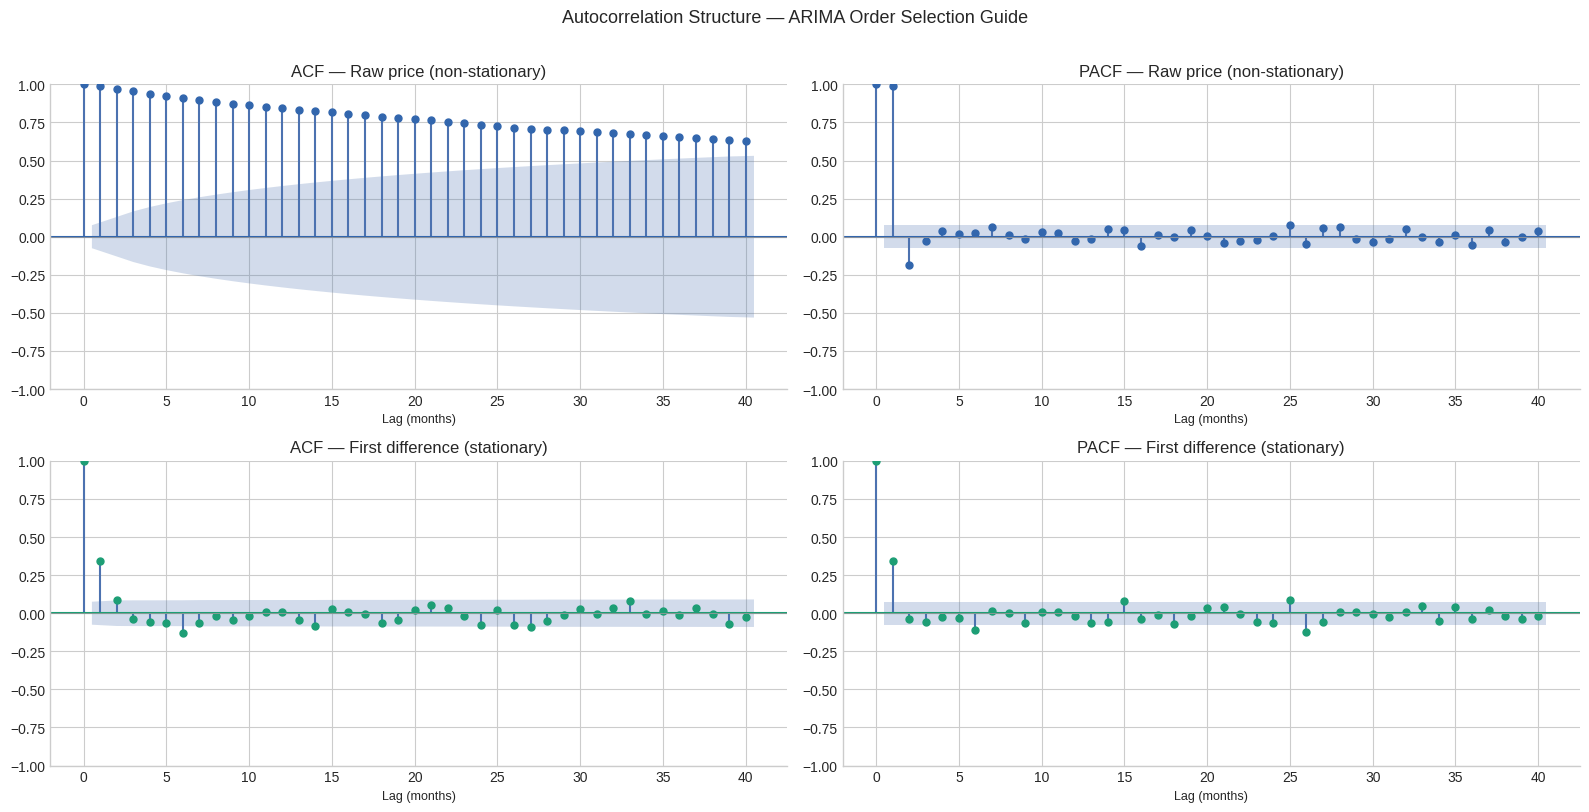


Interpretation guide for ARIMA order selection (first 10 lags):
  95% confidence bound: ±0.0755

  Significant ACF lags  (→ MA terms): [1, 2, 6]
  Significant PACF lags (→ AR terms): [1, 6]

  → Suggested ARIMA starting point: ARIMA(1,1,1) — auto-ARIMA will refine this.


In [15]:
diff_series = df['price'].diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# ── Raw price ACF / PACF ───────────────────────────────────────────────────
plot_acf( df['price'],   ax=axes[0][0], lags=40, color=C_BLUE,   title='ACF — Raw price (non-stationary)')
plot_pacf(df['price'],   ax=axes[0][1], lags=40, color=C_BLUE,   title='PACF — Raw price (non-stationary)')

# ── Differenced series ACF / PACF ─────────────────────────────────────────
plot_acf( diff_series,   ax=axes[1][0], lags=40, color=C_TEAL,   title='ACF — First difference (stationary)')
plot_pacf(diff_series,   ax=axes[1][1], lags=40, color=C_TEAL,   title='PACF — First difference (stationary)')

for ax in axes.flat:
    ax.axhline(0,  color='#999', lw=0.6)
    ax.set_xlabel('Lag (months)', fontsize=9)

plt.suptitle('Autocorrelation Structure — ARIMA Order Selection Guide',
             fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_acf_pacf.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation guidance
acf_vals  = acf(diff_series,  nlags=10)
pacf_vals = pacf(diff_series, nlags=10)
conf = 1.96 / np.sqrt(len(diff_series))  # 95% confidence bound

print("\nInterpretation guide for ARIMA order selection (first 10 lags):")
print(f"  95% confidence bound: ±{conf:.4f}")
print()

sig_acf  = [i for i, v in enumerate(acf_vals[1:],  1) if abs(v) > conf]
sig_pacf = [i for i, v in enumerate(pacf_vals[1:], 1) if abs(v) > conf]

print(f"  Significant ACF lags  (→ MA terms): {sig_acf}")
print(f"  Significant PACF lags (→ AR terms): {sig_pacf}")
print()
print("  → Suggested ARIMA starting point: ARIMA(1,1,1) — auto-ARIMA will refine this.")

---
## 9 — Log-Returns Deep Dive

Log returns are the standard unit of analysis in quantitative finance.  
We look at return distribution, tail risk, and the volatility clustering effect.

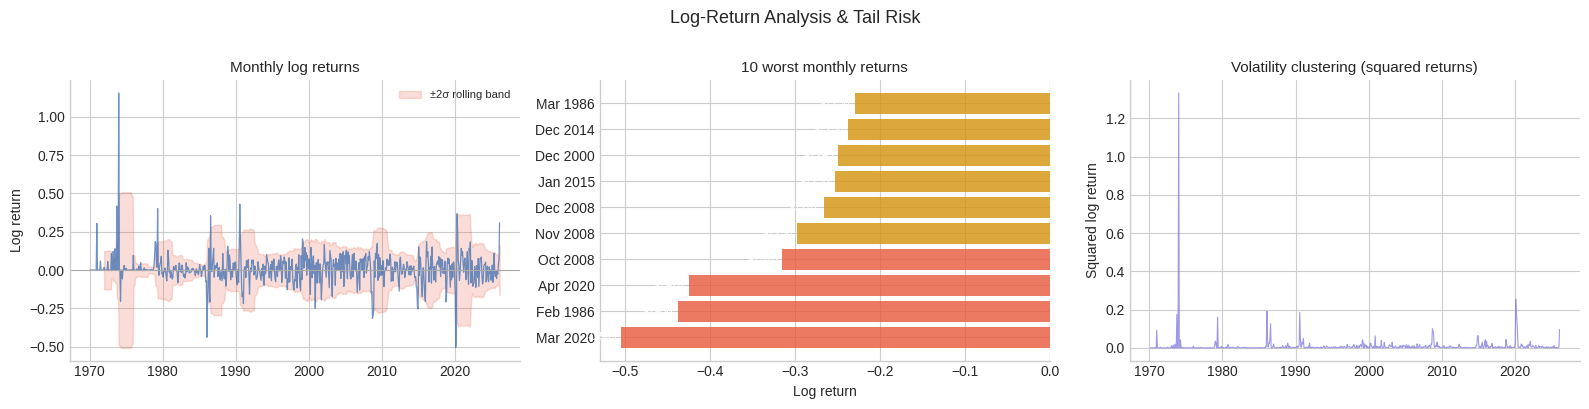

Log-return statistics:
  Mean          : 0.0064
  Std deviation : 0.0970
  Skewness      : 2.2667
  Excess kurtosis: 32.6275  (>0 = heavier tails than normal)
  Worst month   : 2020-03-01 (-0.5049)
  Best month    : 1974-01-01 (1.1540)


In [16]:
log_ret = df['log_return'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Left: log-return time series with ±2σ bands ────────────────────────────
ax = axes[0]
rolling_vol = log_ret.rolling(24).std()
ax.plot(log_ret.index, log_ret, color=C_BLUE, lw=0.9, alpha=0.7)
ax.fill_between(log_ret.index, -2*rolling_vol, 2*rolling_vol, alpha=0.2, color=C_RED,
                label='±2σ rolling band')
ax.axhline(0, color='#aaa', lw=0.8)
ax.set_ylabel('Log return', fontsize=10)
ax.set_title('Monthly log returns', fontsize=11, fontweight='medium')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.legend(fontsize=8)

# ── Middle: tail risk — top 10 largest drops ──────────────────────────────
ax = axes[1]
worst = log_ret.nsmallest(10).sort_values()
colors_bar = [C_RED if v < -0.3 else C_AMBER for v in worst]
bars = ax.barh([d.strftime('%b %Y') for d in worst.index], worst.values,
               color=colors_bar, alpha=0.8)
ax.axvline(0, color='#aaa', lw=0.8)
ax.set_xlabel('Log return', fontsize=10)
ax.set_title('10 worst monthly returns', fontsize=11, fontweight='medium')
for bar, val in zip(bars, worst.values):
    ax.text(val - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='right', va='center', fontsize=7.5, color='white')

# ── Right: squared returns (ARCH effect / volatility clustering) ───────────
ax = axes[2]
sq_returns = log_ret ** 2
ax.plot(sq_returns.index, sq_returns, color=C_PURPLE, lw=0.8, alpha=0.75)
ax.set_ylabel('Squared log return', fontsize=10)
ax.set_title('Volatility clustering (squared returns)', fontsize=11, fontweight='medium')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(10))

plt.suptitle('Log-Return Analysis & Tail Risk', fontsize=13, fontweight='medium', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_log_returns.png'), dpi=150, bbox_inches='tight')
plt.show()

# Key stats
print(f"Log-return statistics:")
print(f"  Mean          : {log_ret.mean():.4f}")
print(f"  Std deviation : {log_ret.std():.4f}")
print(f"  Skewness      : {log_ret.skew():.4f}")
print(f"  Excess kurtosis: {log_ret.kurtosis():.4f}  (>0 = heavier tails than normal)")
print(f"  Worst month   : {log_ret.idxmin().date()} ({log_ret.min():.4f})")
print(f"  Best month    : {log_ret.idxmax().date()} ({log_ret.max():.4f})")

---
## 10 — Correlation Heatmap of Engineered Features

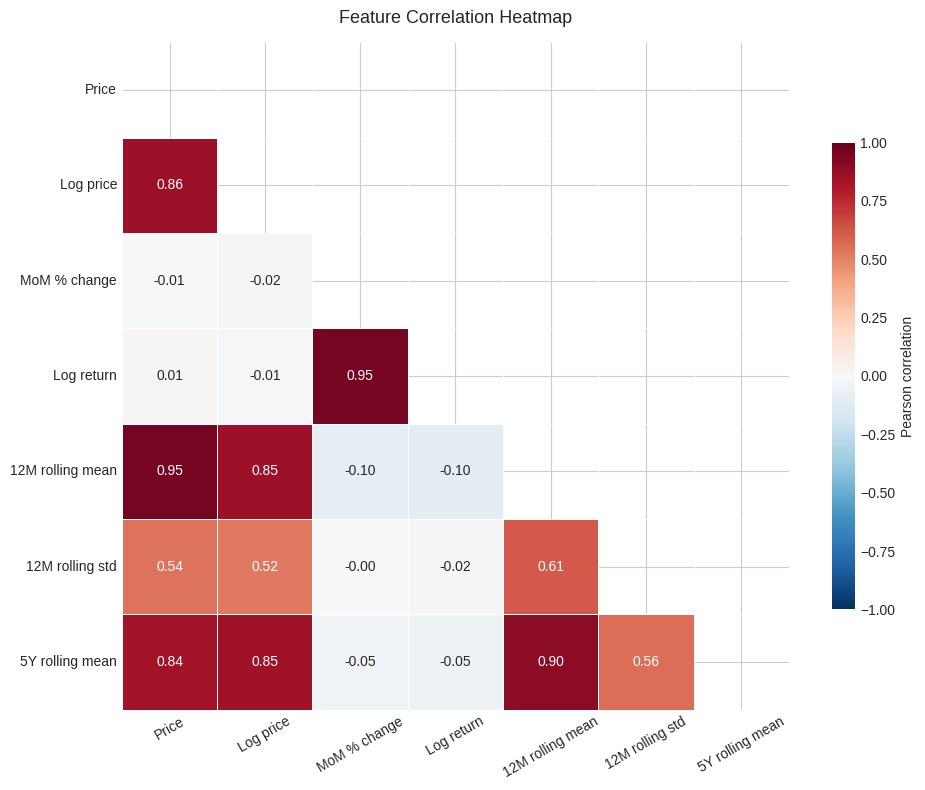

Interpretation notes:
  • Price & log price are highly correlated → log is a monotonic transform.
  • MoM % change & log return are nearly identical at low values.
  • Rolling std correlates moderately with price — higher prices bring more volatility.
  • Log return is near-zero correlated with price level — confirms stationarity.


In [17]:
corr_cols = ['price', 'price_log', 'pct_change', 'log_return',
             'rolling_mean_12', 'rolling_std_12', 'rolling_mean_60']

corr_labels = {
    'price'           : 'Price',
    'price_log'       : 'Log price',
    'pct_change'      : 'MoM % change',
    'log_return'      : 'Log return',
    'rolling_mean_12' : '12M rolling mean',
    'rolling_std_12'  : '12M rolling std',
    'rolling_mean_60' : '5Y rolling mean',
}

corr_df = df[corr_cols].rename(columns=corr_labels).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, ax=ax,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Pearson correlation'}
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='medium', pad=14)
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['figures'], '01_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Interpretation notes:")
print("  • Price & log price are highly correlated → log is a monotonic transform.")
print("  • MoM % change & log return are nearly identical at low values.")
print("  • Rolling std correlates moderately with price — higher prices bring more volatility.")
print("  • Log return is near-zero correlated with price level — confirms stationarity.")

---
## 11 — EDA Summary: Key Findings

Run this cell to generate a clean findings summary you can paste into your README or LinkedIn post.

In [18]:
worst_month  = df['pct_change'].idxmin()
best_month   = df['pct_change'].idxmax()
most_volatile_decade = decade_stats['CV (%)'].idxmax()

summary = f"""
╔══════════════════════════════════════════════════════════════════╗
  EDA KEY FINDINGS — Crude Oil Price 1970–2026
╚══════════════════════════════════════════════════════════════════╝

  Dataset
  ─────────────────────────────────────────────────────────────────
  • {len(df)} monthly observations, zero missing values
  • Range: {df.index.min().date()} → {df.index.max().date()}

  Price extremes
  ─────────────────────────────────────────────────────────────────
  • All-time low  : ${df['price'].min():.2f}/bbl  ({df['price'].idxmin().date()})
  • All-time high : ${df['price'].max():.2f}/bbl  ({df['price'].idxmax().date()})
  • 56-year mean  : ${df['price'].mean():.2f}/bbl

  Biggest single-month moves
  ─────────────────────────────────────────────────────────────────
  • Worst drop  : {df.loc[worst_month, 'pct_change']:.1f}%  ({worst_month.date()})
  • Biggest jump: +{df.loc[best_month, 'pct_change']:.1f}%  ({best_month.date()})

  Volatility
  ─────────────────────────────────────────────────────────────────
  • Most volatile decade (by CV): {most_volatile_decade}s  (CV = {decade_stats.loc[most_volatile_decade, 'CV (%)']:.1f}%)
  • Price is right-skewed (skew = {df['price'].skew():.2f}) and leptokurtic (kurt = {df['price'].kurtosis():.2f})
  • ADF test confirms price is I(1) — requires first differencing for ARIMA
  • Log returns are stationary and exhibit volatility clustering (ARCH effect present)

  Seasonal signal
  ─────────────────────────────────────────────────────────────────
  • Seasonal component is weak relative to trend in multiplicative decomposition
  • Strongest average gains: {MONTH_NAMES[monthly_ret.idxmax()-1]} (+{monthly_ret.max():.2f}%)
  • Weakest average gains : {MONTH_NAMES[monthly_ret.idxmin()-1]} ({monthly_ret.min():.2f}%)

  Model readiness
  ─────────────────────────────────────────────────────────────────
  • Use d=1 for ARIMA (confirmed by ADF test)
  • ACF/PACF on differenced series suggests ARIMA(1,1,1) as baseline
  • Log returns suitable for GARCH-family volatility models
  • All features saved to oil_clean.csv — ready for 02_event_analysis.ipynb
"""
print(summary)

# Save summary as text file
summary_path = os.path.join(PATHS['root'], 'eda_summary.txt')
with open(summary_path, 'w') as f:
    f.write(summary)
print(f"✅ Summary saved → {summary_path}")


╔══════════════════════════════════════════════════════════════════╗
  EDA KEY FINDINGS — Crude Oil Price 1970–2026
╚══════════════════════════════════════════════════════════════════╝

  Dataset
  ─────────────────────────────────────────────────────────────────
  • 675 monthly observations, zero missing values
  • Range: 1970-01-01 → 2026-03-01

  Price extremes
  ─────────────────────────────────────────────────────────────────
  • All-time low  : $1.21/bbl  (1970-01-01)
  • All-time high : $132.83/bbl  (2008-07-01)
  • 56-year mean  : $39.80/bbl

  Biggest single-month moves
  ─────────────────────────────────────────────────────────────────
  • Worst drop  : -39.6%  (2020-03-01)
  • Biggest jump: +217.1%  (1974-01-01)

  Volatility
  ─────────────────────────────────────────────────────────────────
  • Most volatile decade (by CV): 1970s  (CV = 91.6%)
  • Price is right-skewed (skew = 0.89) and leptokurtic (kurt = -0.24)
  • ADF test confirms price is I(1) — requires first differ

---
## Figures Saved This Notebook

All charts are saved to `outputs/figures/` in your Drive project folder:

| File | Description |
|---|---|
| `01_hero_chart.png` | Full annotated price series — portfolio hero visual |
| `01_distributions.png` | Price distribution, Q-Q plot, log-return distribution |
| `01_decade_analysis.png` | Boxplots and mean/CV by decade |
| `01_seasonal.png` | Monthly seasonality charts |
| `01_heatmap_year_month.png` | 56-year year × month price heatmap |
| `01_decomposition.png` | Multiplicative trend-seasonal-residual decomposition |
| `01_volatility_regimes.png` | High/low volatility regime shading |
| `01_stationarity.png` | Raw vs differenced series comparison |
| `01_acf_pacf.png` | ACF/PACF for ARIMA order selection |
| `01_log_returns.png` | Log-return series, tail risk, volatility clustering |
| `01_correlation_heatmap.png` | Feature correlation matrix |

**Next:** Open `02_event_analysis.ipynb` to quantify the impact of each geopolitical shock.